# Module 2 — Sentiment / Emotion Classifier

**Goal:** classify the tone of a customer message as **negative / neutral / positive**, tuning the
responses (an angry customer needs a more apologetic, priority-flagged path).

**Data:** [dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion) — 20k Twitter messages labelled
with 6 emotions, mapped to 3 buckets:
- **negative** ← *sadness, anger, fear*
- **neutral** ← *surprise*
- **positive** ← *joy, love*

**Model (RNN, per the assignment):** `Embedding → BiLSTM/GRU → mean+max pooling → 3-way head`, trained
end-to-end on CPU.

**Domain-shift handling (the key challenge):** emotion is *Twitter* text but our domain is *customer
support*. Twitter has a strong negative prior and no support vocabulary. We therefore:
1. balance the train set across the 3 buckets,
2. augment with real neutral support queries sampled from the Bitext KB, synthetic support-style
   negative/positive messages, and a small hand-labeled set of real support messages,
3. **select the checkpoint on a *support-domain* validation set** instead of the biased Twitter split.

This deliberately trades a little Twitter accuracy for much stronger support-domain tone detection —
see `docs/design_decisions.md`.


In [1]:
import sys, json, random
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import joblib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix
from src.config import (EMOTION_DATASET, EMOTION_ID2LABEL, EMOTION_TO_BUCKET,
                        SENTIMENT_BUCKETS, SENTIMENT_DIR, DATA_DIR)
from src.preprocessing import normalize_text, build_vocab
from src.models.sentiment_model import RNNSentimentModel, train_epoch, evaluate
import scripts.augment as augment
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(0); random.seed(0)
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
MAX_LEN, BATCH, EPOCHS, CELL, HIDDEN, EMBED = 64, 128, 15, 'gru', 128, 128

In [2]:
ds = load_dataset(EMOTION_DATASET)
df = {s: ds[s].to_pandas() for s in ['train','validation','test']}
for s, d in df.items():
    d['bucket'] = d['label'].map(lambda l: EMOTION_TO_BUCKET[EMOTION_ID2LABEL[l]])
    d['clean'] = d['text'].apply(lambda t: normalize_text(t))
print('Mapping 6 emotions -> 3 buckets:')
for k, v in EMOTION_TO_BUCKET.items(): print(f'   {k:8s}-> {v}')
print('\nTrain bucket distribution:\n', df['train']['bucket'].value_counts())

Mapping 6 emotions -> 3 buckets:
   sadness -> negative
   anger   -> negative
   fear    -> negative
   joy     -> positive
   love    -> positive
   surprise-> neutral

Train bucket distribution:
 bucket
negative    8762
positive    6666
neutral      572
Name: count, dtype: int64


In [3]:
with open(DATA_DIR / 'support_tone_samples.json') as fh: hand = json.load(fh)
pool = {'negative': [], 'neutral': [], 'positive': []}
for s in hand: pool[s['bucket']].append(normalize_text(s['text']))
aug = augment.load_augmentation(n_neutral=2500, n_syn=700)
pool['neutral'] += [normalize_text(t) for t in aug['neutral']]
pool['negative'] += [normalize_text(t) for t in aug['negative']]
pool['positive'] += [normalize_text(t) for t in aug['positive']]
n = min(len(v) for v in pool.values())
su_texts, su_labels = [], []
for b, txts in pool.items():
    chosen = random.sample(txts, n)
    su_texts += chosen; su_labels += [SENTIMENT_BUCKETS.index(b)] * n
paired = list(zip(su_texts, su_labels)); random.shuffle(paired)
SU_VAL = int(len(paired) * 0.15); su_val, su_train = paired[:SU_VAL], paired[SU_VAL:]
print(f'Support-style pool balanced at n={n} -> train={len(su_train)} val={len(su_val)}')

Support-style pool balanced at n=719 -> train=1834 val=323


In [4]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts, self.labels, self.vocab = texts, labels, vocab
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        toks = [self.vocab.get(w, 1) for w in self.texts[i].split()][:MAX_LEN]
        return torch.tensor(toks, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)
def collate(batch):
    xs, ys = zip(*batch)
    m = max(len(x) for x in xs)
    padded = torch.zeros(len(xs), m, dtype=torch.long)
    for i, x in enumerate(xs): padded[i, :len(x)] = x
    return padded, torch.tensor(ys)
def macro_acc(y_true, y_pred):
    return np.mean([np.mean([p == t for p, t in zip(y_pred, y_true) if t == c]) for c in set(y_true)])
train_aug = pd.concat([
    df['train'][df['train']['bucket'] == b].sample(df['train']['bucket'].value_counts().min(), random_state=0)
    for b in SENTIMENT_BUCKETS])
extra = pd.DataFrame({'clean': [t for t, _ in su_train],
                      'bucket': [SENTIMENT_BUCKETS[l] for _, l in su_train]})
train_aug = pd.concat([train_aug, extra], ignore_index=True).sample(frac=1, random_state=0)
vocab = build_vocab(train_aug['clean'], min_freq=1, max_size=30_000)
tr_ds = TextDataset(train_aug['clean'].tolist(), train_aug['bucket'].map(SENTIMENT_BUCKETS.index).tolist(), vocab)
va_ds = TextDataset(df['validation']['clean'].tolist() + [t for t,_ in su_val],
                    df['validation']['bucket'].map(SENTIMENT_BUCKETS.index).tolist() + [l for _,l in su_val], vocab)
te_ds = TextDataset(df['test']['clean'], df['test']['bucket'].map(SENTIMENT_BUCKETS.index).tolist(), vocab)
su_ds = TextDataset([normalize_text(s['text']) for s in hand],
                    [SENTIMENT_BUCKETS.index(s['bucket']) for s in hand], vocab)
tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True, collate_fn=collate)
va_loader = DataLoader(va_ds, batch_size=BATCH, collate_fn=collate)
te_loader = DataLoader(te_ds, batch_size=BATCH, collate_fn=collate)
su_loader = DataLoader(su_ds, batch_size=64, collate_fn=collate)
print(f'vocab={len(vocab)}  train={len(train_aug)}  support-val={(len(df["validation"]) + len(su_val))}')

vocab=4725  train=3550  support-val=2323


In [5]:
device = torch.device('cpu')
model = RNNSentimentModel(len(vocab), embedding_dim=EMBED, hidden_dim=HIDDEN,
                          num_classes=len(SENTIMENT_BUCKETS), cell=CELL, padding_idx=0).to(device)
print(f'Parameters = {sum(p.numel() for p in model.parameters()):,}')
opt = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-5)
best = -1.0
for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, tr_loader, opt, device)
    _, _, va_pred, va_true = evaluate(model, va_loader, device)
    score = macro_acc(va_true, va_pred)
    print(f'epoch {ep:02d} | train acc={tr_acc:.4f} | val (support+twitter) macro={score:.4f}')
    if score > best:
        best = score
        torch.save({'state_dict': model.state_dict(), 'config': {'vocab_size': len(vocab),
                    'cell': CELL, 'hidden': HIDDEN, 'embed': EMBED, 'num_classes': len(SENTIMENT_BUCKETS)}},
                   SENTIMENT_DIR / 'sentiment.pt')
print('\nBest checkpoint saved with', CELL.upper(), 'architecture')

Parameters = 935,043


epoch 01 | train acc=0.5997 | val (support+twitter) macro=0.5629


epoch 02 | train acc=0.7961 | val (support+twitter) macro=0.6331


epoch 03 | train acc=0.9003 | val (support+twitter) macro=0.7413


epoch 04 | train acc=0.9423 | val (support+twitter) macro=0.7455


...

epoch 11 | train acc=0.9992 | val (support+twitter) macro=0.8020


epoch 12 | train acc=0.9992 | val (support+twitter) macro=0.8014


epoch 13 | train acc=0.9994 | val (support+twitter) macro=0.7967


epoch 14 | train acc=0.9983 | val (support+twitter) macro=0.8000


epoch 15 | train acc=0.9992 | val (support+twitter) macro=0.8049

Best checkpoint saved with GRU architecture


In [6]:
model.load_state_dict(torch.load(SENTIMENT_DIR / 'sentiment.pt', weights_only=False)['state_dict'])
_, te_acc, te_pred, te_true = evaluate(model, te_loader, device)
print('[twitter test] accuracy =', f'{te_acc:.4f}')
print(classification_report(te_true, te_pred, target_names=SENTIMENT_BUCKETS, zero_division=0))

[twitter test] accuracy = 0.7185
              precision    recall  f1-score   support

    negative       0.78      0.73      0.76      1080
     neutral       0.34      0.97      0.50        66
    positive       0.73      0.68      0.71       854

    accuracy                           0.72      2000
   macro avg       0.62      0.79      0.65      2000
weighted avg       0.74      0.72      0.73      2000



[customer-support qualitative set] accuracy = 0.8923
              precision    recall  f1-score   support

    negative       1.00      0.92      0.96        24
     neutral       0.90      0.82      0.86        22
    positive       0.78      0.95      0.86        19

    accuracy                           0.89        65
   macro avg       0.89      0.89      0.89        65
weighted avg       0.90      0.89      0.89        65



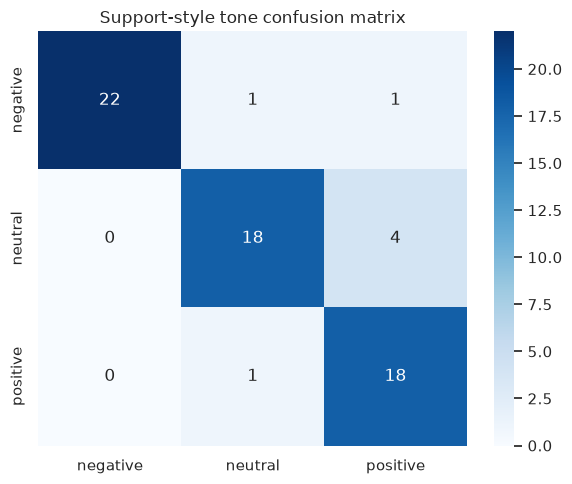

In [7]:
_, su_acc, su_pred, su_true = evaluate(model, su_loader, device)
print('[customer-support qualitative set] accuracy =', f'{su_acc:.4f}')
print(classification_report(su_true, su_pred, target_names=SENTIMENT_BUCKETS, zero_division=0))
cm = confusion_matrix(su_true, su_pred, labels=range(3))
plt.figure(figsize=(6, 5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENT_BUCKETS, yticklabels=SENTIMENT_BUCKETS)
plt.title('Support-style tone confusion matrix'); plt.tight_layout(); plt.show()

In [8]:
joblib.dump(vocab, SENTIMENT_DIR / 'vocab.joblib')
joblib.dump(SENTIMENT_BUCKETS, SENTIMENT_DIR / 'buckets.joblib')
from src.models.sentiment import SentimentClassifier
sc = SentimentClassifier()
for m in ["I have been waiting for three weeks and nobody helps, this is infuriating",
          "Could you tell me the delivery options for my area?",
          "Got my order today, absolutely delighted, thank you!"]:
    r = sc.predict(m)
    print(f'{r["sentiment"]:8s} (conf={r["confidence"]:.2f})  {m}')
print('\nArtifacts saved to', SENTIMENT_DIR)

negative (conf=1.00)  I have been waiting for three weeks and nobody helps, this is infuriating
neutral  (conf=0.49)  Could you tell me the delivery options for my area?
positive (conf=1.00)  Got my order today, absolutely delighted, thank you!

Artifacts saved to /media/mosaab/01DC3BA86FD6B9C0/Projects/ITI/NLP/project/artifacts/sentiment
